In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Dropout, Sequential, ReLU, MultiheadAttention, LayerNorm, BatchNorm1d
from torch_geometric.nn import GraphNorm
from torch_geometric.nn import GCNConv, GINEConv, global_mean_pool

class GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, args):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.norm1 = GraphNorm(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.norm2 = GraphNorm(hidden_channels)

        self.lin = Linear(hidden_channels, num_classes)
        self.dropout = Dropout(dropout)

        self.fc_out = Linear(hidden_channels, num_classes)
        self.batch_norm = BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        x = self.batch_norm(x)

        return x


class GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, args):
        super(GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)
        # self.batch_norm = BatchNorm1d(hidden_channels)


    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        # x = self.batch_norm(x)

        return x


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
        )

    def forward(self, x):
        return self.mlp(x)

class ProjectionHead_PCL(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
            nn.BatchNorm1d(proj_dim)
        )

    def forward(self, x):
        return self.mlp(x)

class Cluster_GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, args):
        super(Cluster_GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x



In [5]:
import torch
from tqdm import tqdm
from torch_geometric.utils import subgraph
from torch_geometric.utils import to_networkx, from_networkx
import networkx as nx
import random
from torch_geometric.utils import to_dense_adj, dense_to_sparse
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

class Graph_Augmentation_Helper():
    def __init__(self, positive_samples, args):
        self.pos_samples = positive_samples
        self.aug_types = args.aug_types
        self.random_state = args.random_state
        self.test_size = args.test_size

        # augmentation configs
        self.shuffle_ratio = args.shuffle_ratio
        self.noise_ratio = args.noise_ratio
        self.noise_std = args.noise_std
        self.node_drop_ratio = args.node_drop_ratio
        self.edge_drop_ratio = args.edge_drop_ratio
        self.edge_add_ratio = args.edge_add_ratio
        self.alpha = args.alpha
        self.PPR_drop_ratio = args.PPR_drop_ratio
        self.PPR_add_ratio = args.PPR_add_ratio
        self.K = args.K


    def node_feature_shuffle(self, samples, shuffle_ratio):
        shuffled_samples = []
        for data in tqdm(samples, desc='Augment graph by node feature shuffling...'):
            num_features = data.x.size(1)
            num_shuffle = int(num_features * shuffle_ratio)

            perm = torch.randperm(num_features)
            shuffle_idx = perm[:num_shuffle]

            shuffled_x = data.x.clone()
            shuffled_x[:, shuffle_idx] = data.x[torch.randperm(data.x.size(0))][:, shuffle_idx]

            new_data = data.clone()
            new_data.x = shuffled_x
            new_data.id = int(str(data.id) + '000')
            shuffled_samples.append(new_data)

        return shuffled_samples
    

    def node_feature_noise_masking(self, samples, noise_ratio, noise_std):
        noise_masked_samples = []
        for data in tqdm(samples, desc='Augment graph by noise masking...'):
            x = data.x.clone()

            mask = torch.rand_like(x) < noise_ratio  

            noise = torch.randn_like(x) * noise_std
            x_noisy = x + noise * mask 

            new_data = data.clone()
            new_data.x = x_noisy
            new_data.id = int(str(data.id) + '001')
            noise_masked_samples.append(new_data)
        
        return noise_masked_samples


    def node_dropping(self, samples, drop_ratio=0.2):
        """

        """
        dropped_samples = []
        for data in tqdm(samples, desc='Augment graph by node dropping...'):
            num_nodes = data.n_nodes
            
            num_drop = max(1, int(num_nodes * drop_ratio))  # at less drop one node
            drop_nodes = torch.randperm(num_nodes)[:num_drop]
            
            keep_mask = torch.ones(num_nodes, dtype=torch.bool)
            keep_mask[drop_nodes] = False
            keep_nodes = keep_mask.nonzero(as_tuple=False).view(-1)
            
            edge_index, edge_attr = subgraph(
                subset=keep_nodes,
                edge_index=data.edge_index,
                edge_attr=data.edge_attr if hasattr(data, "edge_attr") else None,
                relabel_nodes=True, 
                num_nodes=num_nodes
            )
            
            new_data = data.clone()
            new_data.x = data.x[keep_nodes]
            new_data.edge_index = edge_index
            new_data.edge_attr = edge_attr
            new_data.n_nodes = keep_nodes.size(0)
            new_data.id = int(str(data.id) + '010')
            dropped_samples.append(new_data)
        
        return dropped_samples
    

    def edge_perturbation_weighted(self, samples, drop_ratio, add_ratio):
        """

        """
        edge_perturbation_weighted_samples = []
        for data in tqdm(samples, desc='Augment graph by edge perturbation weighting...'):
            num_nodes = data.x.size(0)
            G = to_networkx(data, to_undirected=True)
            nodes_list = range(num_nodes)
            center_node = random.choice(nodes_list)
             
            lengths = dict(nx.single_source_shortest_path_length(G, center_node))

            max_hop = max(lengths.values()) if lengths else 0
            default_hop = max_hop + 1
            
            deg = dict(G.degree())
            
            edge_list = list(G.edges())
            edge_weights = []
            for (u, v) in edge_list:

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                hop = min(hop_u, hop_v)

                d_u = deg[u]
                d_v = deg[v]
                d = max(d_u, d_v)

                w = (1.0 / (hop + 1)) * (d / (d + 1))
                edge_weights.append(w)
 
            weights = torch.tensor(edge_weights, dtype=torch.float)
            probs = weights / weights.sum()
            

            num_drop = max(1, int(len(edge_list) * drop_ratio))
            drop_idx = torch.multinomial(probs, num_drop, replacement=False).tolist()
            drop_edges = [edge_list[i] for i in drop_idx]
            for (u,v) in drop_edges:
                if G.has_edge(u,v):
                    G.remove_edge(u, v)

            num_add = int(len(edge_list) * add_ratio)

            node_pairs = []
            attempts = 0
            while len(node_pairs) < num_add and attempts < num_add * 10:
                u = random.randrange(num_nodes)
                v = random.randrange(num_nodes)
                if u==v or G.has_edge(u,v):
                    attempts += 1
                    continue

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                if abs(hop_u - hop_v) > 0:  
                    G.add_edge(u, v)
                    node_pairs.append((u, v))
                attempts += 1
            

            new_edge_index = from_networkx(G)
            new_data = data.clone()
            new_data.x = data.x
            new_data.edge_index = new_edge_index.edge_index
            if hasattr(data, 'edge_attr'):
                new_data.edge_attr = torch.zeros((new_data.edge_index.size(1), data.edge_attr.size(1)))
            new_data.id = int(str(data.id) + '011')
            
            edge_perturbation_weighted_samples.append(new_data)

        return edge_perturbation_weighted_samples
    

    def personalized_pagerank_augmentation(self, samples, alpha, drop_ratio, add_ratio, K):
        """
        Personalized PageRank (PPR) based graph augmentation
        Args:
            data: PyG Data 对象
            alpha: teleport 概率（默认 0.15）
            drop_ratio: 删除边比例
            add_ratio: 添加边比例
        """
        PPR_samples = []

        for data in tqdm(samples, desc='Augment graph by personalized pagerank...'):
            num_nodes = data.num_nodes
            edge_index = data.edge_index

            # Step 1: 构建对称邻接矩阵
            A = to_dense_adj(edge_index, max_num_nodes=num_nodes).squeeze(0)
            A = (A + A.t()) / 2
            A.fill_diagonal_(0)

            # Step 2: 归一化邻接矩阵
            deg = A.sum(dim=1)
            deg_inv_sqrt = torch.pow(deg, -0.5)
            deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0
            D_inv_sqrt = torch.diag(deg_inv_sqrt)
            A_hat = D_inv_sqrt @ A @ D_inv_sqrt

            # Step 3: 近似计算 Personalized PageRank 矩阵
            P = torch.eye(num_nodes)
            M = torch.eye(num_nodes)
            for _ in range(K):
                M = (1 - alpha) * A_hat @ M
                P += M
            P = alpha * P

            # Step 4: 删除边
            edge_list = edge_index.t().tolist()
            edge_scores = [P[i, j].item() for i, j in edge_list]
            num_drop = int(len(edge_list) * drop_ratio)
            if num_drop > 0:
                weights = torch.tensor(edge_scores)
                weights = (weights.max() - weights + 1e-8)  # 分数越小越容易被删
                weights = weights / weights.sum()
                drop_idx = torch.multinomial(weights, num_drop, replacement=False)
                keep_edges = [edge_list[i] for i in range(len(edge_list)) if i not in drop_idx]
            else:
                keep_edges = edge_list

            # Step 5: 添加边
            adj = A.clone()
            num_add = int(len(keep_edges) * add_ratio)
            if num_add > 0:
                candidates = [(i, j) for i in range(num_nodes) for j in range(num_nodes)
                            if adj[i, j] == 0 and i != j]
                if len(candidates) > 0:
                    candidate_scores = torch.tensor([P[i, j].item() for i, j in candidates])
                    probs = candidate_scores / candidate_scores.sum()
                    add_idx = torch.multinomial(probs, min(num_add, len(candidates)), replacement=False)
                    add_edges = [candidates[i] for i in add_idx]
                    keep_edges += add_edges

            new_edge_index = torch.tensor(keep_edges).t().contiguous()

            # Step 6: 构建增强后的图
            new_data = data.clone()
            new_data.edge_index = new_edge_index
            new_data.n_edges = new_edge_index.size(1)
            new_data.edge_attr = data.edge_attr[:new_edge_index.size(1)]  # 直接截断（或重新初始化）
            new_data.id = int(str(data.id) + '100')

            PPR_samples.append(new_data)

        return PPR_samples
    

    def do_augmentation(self):
        print('Start to augment graph data')

        if self.aug_types == 'all':
            # feature-level augmentation
            node_mixup_samples = self.node_feature_shuffle(self.pos_samples, self.shuffle_ratio)
            noise_masking_samples = self.node_feature_noise_masking(self.pos_samples, self.noise_ratio, self.noise_std)
            
            # node and edge level augmentation
            node_dropping_samples = self.node_dropping(self.pos_samples, self.node_drop_ratio)
            edge_perturbation_weighted_samples = self.edge_perturbation_weighted(self.pos_samples, self.edge_drop_ratio, self.edge_add_ratio)

            # graph-level augmetation
            PPR_samples = self.personalized_pagerank_augmentation(self.pos_samples, self.alpha, self.PPR_drop_ratio, self.PPR_add_ratio, self.K)
        
        return self.pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples


    def train_test_split_positive_samples(self):
        pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples = self.do_augmentation()
        
        # split train, test set
        pos_train_set, pos_test_set = train_test_split(pos_samples, test_size=self.test_size, random_state=self.random_state)
        node_mixup_train_set, node_mixup_test_set = train_test_split(node_mixup_samples, test_size=self.test_size, random_state=self.random_state)
        noise_mask_train_set, noise_mask_test_set = train_test_split(noise_masking_samples, test_size=self.test_size, random_state=self.random_state)
        node_drop_train_set, node_drop_test_set = train_test_split(node_dropping_samples, test_size=self.test_size, random_state=self.random_state)
        edge_weight_train_set, edge_weight_test_set = train_test_split(edge_perturbation_weighted_samples, test_size=self.test_size, random_state=self.random_state)
        PPR_train_set, PPR_test_set = train_test_split(PPR_samples, test_size=self.test_size, random_state=self.random_state)

        pos_train_samples = pos_train_set + node_mixup_train_set + noise_mask_train_set + node_drop_train_set + edge_weight_train_set + PPR_train_set
        pos_test_samples = pos_test_set + node_mixup_test_set + noise_mask_test_set + node_drop_test_set + edge_weight_test_set + PPR_test_set

        return pos_train_samples, pos_test_samples


Start to augment graph data


Augment graph by personalized pagerank...: 100%|██████████| 126/126 [00:00<00:00, 147.45it/s]


Model is loaded!
Analyzing UNLABELED samples...


100%|██████████| 176/176 [00:10<00:00, 16.95it/s]


Total samples: 179825, Prototypes: 7


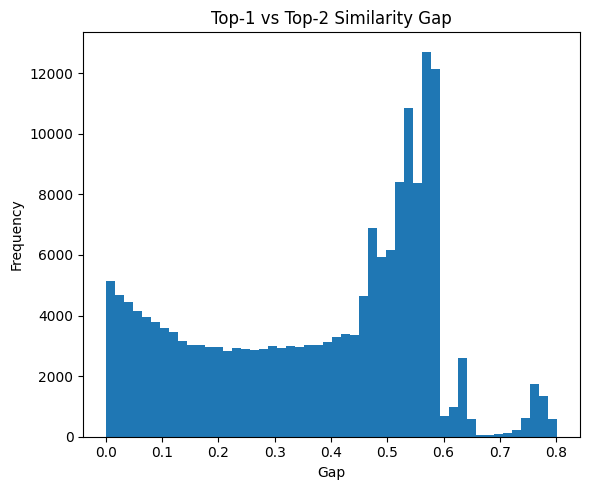

Average gap: 0.3726


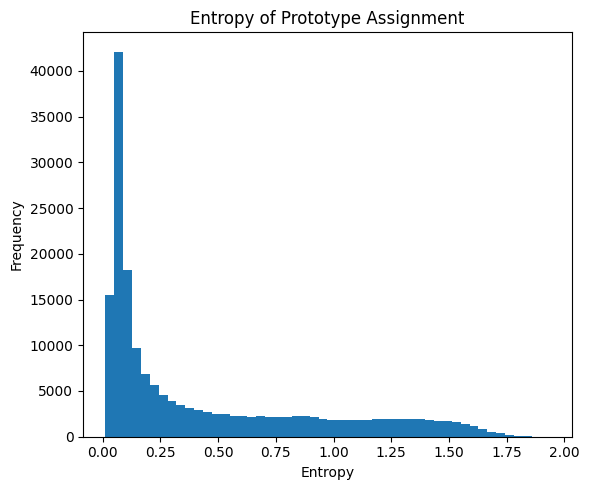

Average entropy: 0.4430


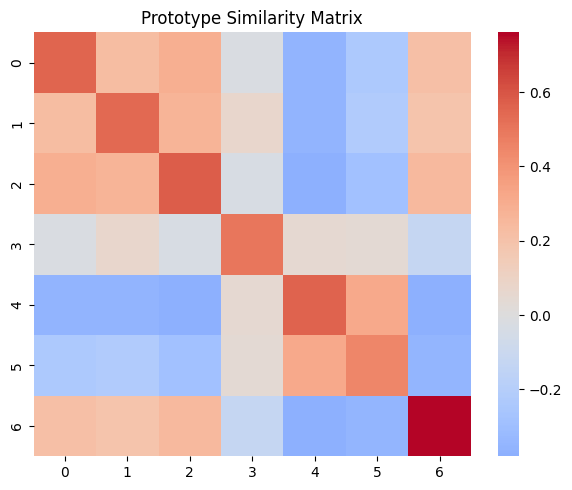

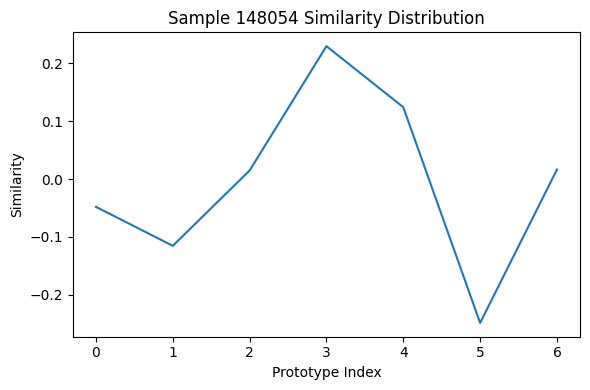

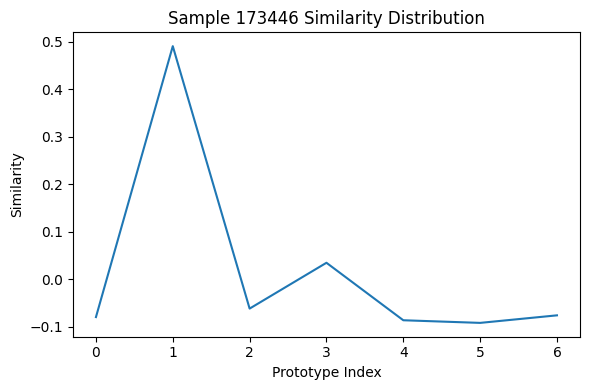

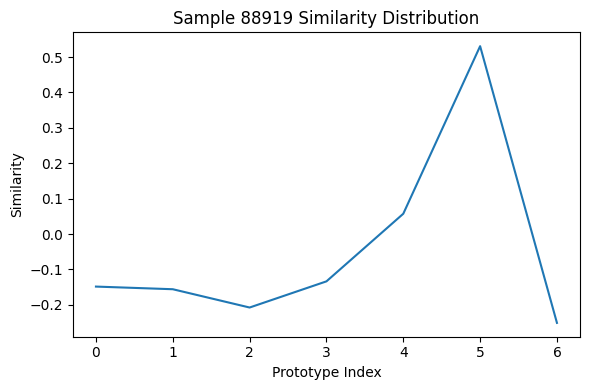

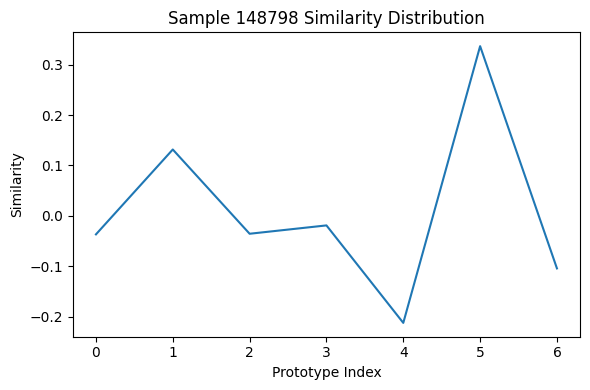

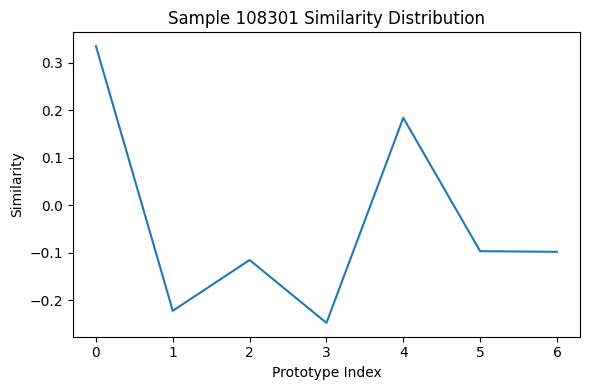

In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import argparse
import pickle
from torch_geometric.loader import DataLoader

from tqdm import tqdm
import pandas as pd
import torch.nn.functional as F
from sklearn.metrics import silhouette_score
import umap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from collections import Counter


parser = argparse.ArgumentParser(description="Train a GCN model")
# unsupervised learning configs
parser = argparse.ArgumentParser(description="Train the model")
parser.add_argument('--analysis', type=bool, default=False, help='Wether to print the summary of the dataset')
parser.add_argument('--usl_batch_size', type=int, default=256, help='Batch size for training')
parser.add_argument('--num_classes', type=int, default=2, help='Number of classes')
parser.add_argument('--usl_learning_rate', type=float, default=0.0005, help='Learning rate')
parser.add_argument('--usl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--epoch', type=int, default=200, help='Number of training epochs')
parser.add_argument('--dropout', type=float, default=0.5, help='Value of dropout')
parser.add_argument('--training_types', type=str, default='Unsupervised learning', help='training_types')
parser.add_argument('--models', type=str, default='GINE', help='Training models')
parser.add_argument('--embed_dim', type=int, default=256, help='Embedding dimension of attention')
parser.add_argument('--num_heads', type=int, default=4, help='Number of heads for attention')
parser.add_argument('--desp_dim', type=int, default=217, help='Number of descriptors')
parser.add_argument('--retrain_usl', type=bool, default=False, help='retrain the usl models')
parser.add_argument('--ucl_trials', type=int, default=10, help='Number of trials for unsupervised learning')
parser.add_argument('--save_path', type=str, default='checkpoints_origin_backup', help='')

# graph augmentation configs
parser.add_argument('--aug_types', type=str, default='all', help='augmentation types')
parser.add_argument('--shuffle_ratio', type=float, default=0.2, help='shuffle ratio')
parser.add_argument('--node_drop_ratio', type=float, default=0.2, help='node drop ratio')
parser.add_argument('--noise_ratio', type=float, default=0.2, help='noise_ratio')
parser.add_argument('--noise_std', type=float, default=0.1, help='noise_std')
parser.add_argument('--edge_drop_ratio', type=float, default=0.1, help='edge drop ratio')
parser.add_argument('--edge_add_ratio', type=float, default=0.05, help='edge add ratio')
parser.add_argument('--alpha', type=float, default=0.15, help='PPR alpha')
parser.add_argument('--PPR_drop_ratio', type=float, default=0.2, help='PPR_drop_ratio')
parser.add_argument('--PPR_add_ratio', type=float, default=0.2, help='PPR_add_ratio')
parser.add_argument('--K', type=int, default=10, help='PPR K')
parser.add_argument('--random_state', type=int, default=42, help='data split random seed')
parser.add_argument('--test_size', type=float, default=0.2, help='test set size')


# prototypes configs
parser.add_argument('--max_cluster', type=int, default=10, help='max cluster number')
parser.add_argument('--temperature', type=float, default=0.1, help='temperature coefficient for prototypes')
parser.add_argument('--proto_epoch', type=int, default=300, help='Number of training epochs')
parser.add_argument('--r', type=int, default=10000, help='number of randomly select neg prototypes')
parser.add_argument('--proto_training_types', type=str, default='Prototype contrastive learning', help='training_types')
parser.add_argument('--proto_models', type=str, default='GINE', help='model name for PCL')
parser.add_argument('--pcl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--pcl_learning_rate', type=float, default=0.00001, help='Learning rate')
parser.add_argument('--pcl_batch_size', type=int, default=1024, help='Batch size for training')
parser.add_argument('--threshold', type=float, default=0.3, help='threshold')
parser.add_argument('--topk', type=int, default=25, help='top k samples for each prototype')

args = parser.parse_args([])
device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')


def load_data(data_path):
    # data preparation
    with open(data_path, 'rb') as f:
        all_data = pickle.load(f)

    positive_samples = all_data[:126] # number of positive samples
    unlabeled_samples = all_data[126:]

    graph_aug_helper = Graph_Augmentation_Helper(positive_samples, args)
    pos_train_samples, pos_test_samples = graph_aug_helper.train_test_split_positive_samples()
    unl_train_samples, unl_test_samples = train_test_split(unlabeled_samples, test_size=args.test_size, random_state=args.random_state)
    return positive_samples, unlabeled_samples, pos_train_samples, pos_test_samples, unl_train_samples, unl_test_samples

data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
file_path = f"/home/hwx/python_project/test/Boron/{args.save_path}/{args.training_types}_model_{args.models}.pth"

# load data
positive_samples_126, unlabeled_samples, pos_train_samples, pos_test_samples, unl_train_samples, unl_test_samples = load_data(data_path)

pos_loader = DataLoader(pos_train_samples + pos_test_samples, batch_size=args.pcl_batch_size, shuffle=False)
unl_loader = DataLoader(unl_train_samples + unl_test_samples, batch_size=args.pcl_batch_size, shuffle=False)


encoder = GINE(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
        hidden_channels=args.pcl_hidden_channels,
        num_classes=args.num_classes, dropout=args.dropout, args=args).to(device)
projection = ProjectionHead_PCL(in_dim=args.pcl_hidden_channels).to(device)
encoder.load_state_dict(torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}/encoder_{args.proto_models}_epoch_{args.proto_epoch}.pth')) # load the checkpoints
projection.load_state_dict(torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}/projection_{args.proto_models}_epoch_{args.proto_epoch}.pth')) # load the checkpoints
proto_centroids = torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}/proto_centroids_{args.proto_models}_epoch_{args.proto_epoch}.pth')

model = Cluster_GINE(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout, args=args).to(device)
model.load_state_dict(torch.load(file_path)) # load the checkpoints
projection_head = ProjectionHead(in_dim=args.usl_hidden_channels).to(device)

print(f'Model is loaded!')

def analyze_similarity_distribution(encoder, projection, dataloader, proto_centroids, temperature=0.1):
    encoder.eval()
    projection.eval()

    all_sims = []

    with torch.no_grad():
        for data in tqdm(dataloader):
            data = data.to(device)
            proto_centroids = proto_centroids.to(device)

            query = encoder(data.x, data.edge_index, data.edge_attr, data.batch)
            query = projection(query)
            query = F.normalize(query, dim=-1)

            sims = query @ proto_centroids.t()  # [B, K]
            all_sims.append(sims.cpu())

    sims = torch.cat(all_sims, dim=0)  # [N, K]

    print(f"Total samples: {sims.shape[0]}, Prototypes: {sims.shape[1]}")

    # =========================
    # 1. Top1 - Top2 Gap
    # =========================
    topk_vals = sims.topk(2, dim=1).values
    top1 = topk_vals[:, 0]
    top2 = topk_vals[:, 1]
    gap = top1 - top2

    plt.figure(figsize=(6,5))
    plt.hist(gap.numpy(), bins=50)
    plt.title("Top-1 vs Top-2 Similarity Gap")
    plt.xlabel("Gap")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("gap_hist.png", dpi=300)
    plt.show()

    print(f"Average gap: {gap.mean().item():.4f}")

    # =========================
    # 2. Entropy
    # =========================
    probs = F.softmax(sims / temperature, dim=1)
    entropy = -(probs * torch.log(probs + 1e-9)).sum(dim=1)

    plt.figure(figsize=(6,5))
    plt.hist(entropy.numpy(), bins=50)
    plt.title("Entropy of Prototype Assignment")
    plt.xlabel("Entropy")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("entropy_hist.png", dpi=300)
    plt.show()

    print(f"Average entropy: {entropy.mean().item():.4f}")

    # =========================
    # 3. Prototype similarity heatmap
    # =========================
    proto_sim = proto_centroids @ proto_centroids.t()
    proto_sim = proto_sim.cpu().numpy()

    plt.figure(figsize=(6,5))
    sns.heatmap(proto_sim, cmap='coolwarm', center=0)
    plt.title("Prototype Similarity Matrix")
    plt.tight_layout()
    plt.savefig("proto_heatmap.png", dpi=300)
    plt.show()

    # =========================
    # 4. Single sample similarity curves
    # =========================
    num_samples_to_plot = 5
    indices = torch.randperm(sims.size(0))[:num_samples_to_plot]

    for i, idx in enumerate(indices):
        plt.figure(figsize=(6,4))
        plt.plot(sims[idx].numpy())
        plt.title(f"Sample {idx.item()} Similarity Distribution")
        plt.xlabel("Prototype Index")
        plt.ylabel("Similarity")
        plt.tight_layout()
        plt.savefig(f"sample_{i}_curve.png", dpi=300)
        plt.show()

    return gap, entropy


print("Analyzing UNLABELED samples...")
gap_unl, entropy_unl = analyze_similarity_distribution(
    encoder, projection, unl_loader, proto_centroids
)